In [ ]:
from backtest_engine import request, Portfolio, PortfolioDynamicCost, StrategyConnector, gen_toy_returns
from datetime import date
import tomllib

with open("config.toml", "rb") as f:
    config = tomllib.load(f)["alpaca-api"]
    
df = request(
    ticker="SPY",
    config=config,
)

spy = df["close"] * 100_000 / df["close"].iloc[0]

# todo: optimise pd -> np
# todo: add comments for functions, incl. param guidelines
# todo: consider refactoring tearsheet and connector into dataclasses

Loading data from local cache: cache_SPY_20170101_20260620.parquet


In [6]:
p = PortfolioDynamicCost(df)
c = StrategyConnector(p, spy, spy)

#print(p.result(decompose=True)) 

"""
print(p.result(start=date(2020, 1, 1), end=date(2021, 1, 1)))
print(p.result(date=date(2025, 4, 12)))
"""

c:\Users\franc\OneDrive\Desktop\NYU\SequoAlpha\1 - SPY Momentum Backtest\SPY-Momentum-Strategy-Backtest\backtest_engine\analysis\connector.py:49: RuntimeWarning: divide by zero encountered in divide
  aums = np.where(weights == 1, self.portfolio.aum, weights * self.book.loc[self.df.index[0]] / (1 - weights))
c:\Users\franc\OneDrive\Desktop\NYU\SequoAlpha\1 - SPY Momentum Backtest\SPY-Momentum-Strategy-Backtest\backtest_engine\analysis\connector.py:138: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Pass' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  self.metrics_df.loc["Incremental Sharpe Test", "combined"] = "Pass" if self.metrics_df.loc["Sharpe", "combined"] > self.metrics_df.loc["Sharpe", "book"] * self.metrics_df.loc["Correlation to Book", "strat"] else "Fail"


'\nprint(p.result(start=date(2020, 1, 1), end=date(2021, 1, 1)))\nprint(p.result(date=date(2025, 4, 12)))\n'

In [7]:
#PortfolioDynamicCost.sharpe_curve(df)

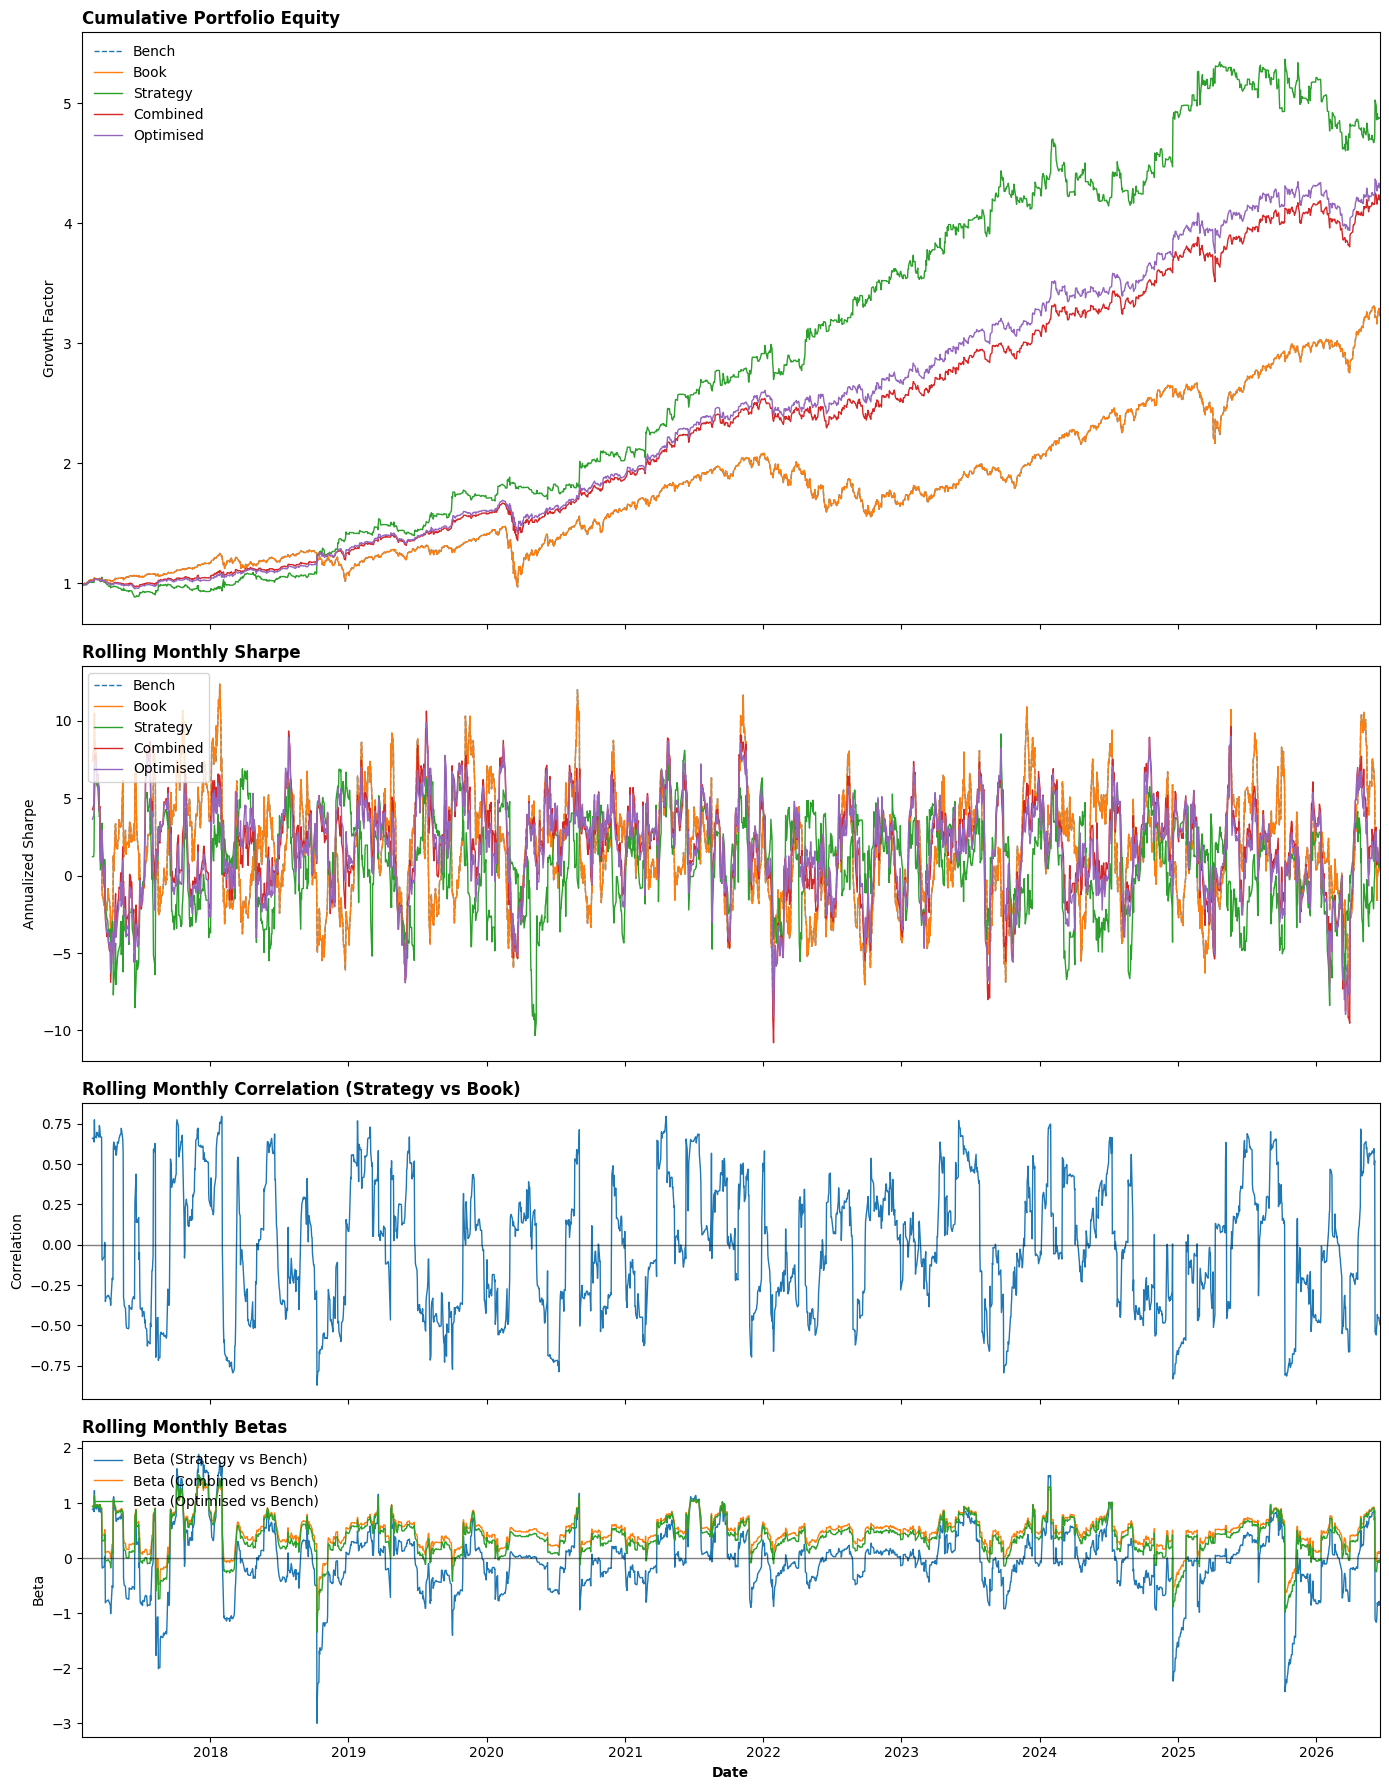

=== Portfolio Integration & Risk Report ===
                                 Book Strategy   Combined  Optimised    Bench
Expected Return                14.30%   18.17%     15.99%     16.23%   14.30%
Volatility                     18.45%   16.07%     11.42%     11.34%   18.45%
Sharpe                           0.77     1.13       1.40       1.43     0.77
Beta                             1.00    -0.10       0.45       0.35     1.00
Skewness                        -0.36     2.58       0.64       0.94    -0.36
Kurtosis                        14.94    20.65       8.75       8.04    14.94
Max Drawdown                  -34.23%  -15.81%    -18.75%    -15.91%  -34.23%
Max DD Days                       512      255        213        153      512
Max DD Recovery Days              103      195         95         95      103
Correlation to Book                 -    -0.11       0.72       0.57        -
Crash Correlation to Book           -    -0.13       0.45       0.29        -
Intraday Correlation

In [8]:
c.report()